In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm


feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from MODELS.model import *
from MODELS.pipeline import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_columns', None)

s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s21['EXPECTED_USAGE_MIN'] = s21['USG_PCT_ROLLING_AVG_5'] * s21['MIN_ROLLING_AVG_5']
s21['EXPECTED_PTS_VOLUME'] = s21['FGA_ROLLING_AVG_5'] * s21['FG_PCT_ROLLING_AVG_5']
s21['PACE_ADJ_MIN'] = s21['MIN_ROLLING_AVG_5'] * s21['EXPECTED_PACE']

s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s22['EXPECTED_USAGE_MIN'] = s22['USG_PCT_ROLLING_AVG_5'] * s22['MIN_ROLLING_AVG_5']
s22['EXPECTED_PTS_VOLUME'] = s22['FGA_ROLLING_AVG_5'] * s22['FG_PCT_ROLLING_AVG_5']
s22['PACE_ADJ_MIN'] = s22['MIN_ROLLING_AVG_5'] * s22['EXPECTED_PACE']

s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s23['EXPECTED_USAGE_MIN'] = s23['USG_PCT_ROLLING_AVG_5'] * s23['MIN_ROLLING_AVG_5']
s23['EXPECTED_PTS_VOLUME'] = s23['FGA_ROLLING_AVG_5'] * s23['FG_PCT_ROLLING_AVG_5']
s23['PACE_ADJ_MIN'] = s23['MIN_ROLLING_AVG_5'] * s23['EXPECTED_PACE']

s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * s24['MIN_ROLLING_AVG_5']
s24['EXPECTED_PTS_VOLUME'] = s24['FGA_ROLLING_AVG_5'] * s24['FG_PCT_ROLLING_AVG_5']
s24['PACE_ADJ_MIN'] = s24['MIN_ROLLING_AVG_5'] * s24['EXPECTED_PACE']

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * s25['MIN_ROLLING_AVG_5']
s25['EXPECTED_PTS_VOLUME'] = s25['FGA_ROLLING_AVG_5'] * s25['FG_PCT_ROLLING_AVG_5']
s25['PACE_ADJ_MIN'] = s25['MIN_ROLLING_AVG_5'] * s25['EXPECTED_PACE']

train_df = pd.concat([s21, s22, s23])
val_df = s24
test_df = s25

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
train_df.tail()

Training data shape: (74988, 690)
Training date range: 2020-12-22 to 2023-04-09
Validation data shape: (26401, 687)
Validation date range: 2023-10-24 to 2024-04-14
Test data shape: (26306, 687)
Test date range: 2024-10-22 to 2025-04-13


,Unnamed: 0,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_SEASON_ID,TEAM_NAME,TEAM_GAME_DATE,TEAM_MATCHUP,TEAM_WL,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,VIDEO_AVAILABLE,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,STARTING,BLOWOUT_RISK,TEAM_IMPLIED_PTS_FAV,TEAM_IMPLIED_PTS_UND,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_EXPANDING_AVG,MIN_EXPANDING_AVG,FGA_EXPANDING_AVG,FTA_EXPANDING_AVG,FG3A_EXPANDING_AVG,FG_PCT_EXPANDING_AVG,FG3_PCT_EXPANDING_AVG,FT_PCT_EXPANDING_AVG,USG_PCT_EXPANDING_AVG,TS_PCT_EXPANDING_AVG,EFG_PCT_EXPANDING_AVG,POSS_EXPANDING_AVG,TCHS_EXPANDING_AVG,AST_EXPANDING_AVG,REB_EXPANDING_AVG,TOV_EXPANDING_AVG,PTS_ROLLING_AVG_3,MIN_ROLLING_AVG_3,FGA_ROLLING_AVG_3,FTA_ROLLING_AVG_3,FG3A_ROLLING_AVG_3,FG_PCT_ROLLING_AVG_3,FG3_PCT_ROLLING_AVG_3,FT_PCT_ROLLING_AVG_3,USG_PCT_ROLLING_AVG_3,TS_PCT_ROLLING_AVG_3,EFG_PCT_ROLLING_AVG_3,POSS_ROLLING_AVG_3,TCHS_ROLLING_AVG_3,AST_ROLLING_AVG_3,REB_ROLLING_AVG_3,TOV_ROLLING_AVG_3,PTS_ROLLING_AVG_5,MIN_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,POSS_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,AST_ROLLING_AVG_5,REB_ROLLING_AVG_5,TOV_ROLLING_AVG_5,PTS_ROLLING_AVG_7,MIN_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FTA_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,FG3_PCT_ROLLING_AVG_7,FT_PCT_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,POSS_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,AST_ROLLING_AVG_7,REB_ROLLING_AVG_7,TOV_ROLLING_AVG_7,PTS_ROLLING_AVG_15,MIN_ROLLING_AVG_15,FGA_ROLLING_AVG_15,FTA_ROLLING_AVG_15,FG3A_ROLLING_AVG_15,FG_PCT_ROLLING_AVG_15,FG3_PCT_ROLLING_AVG_15,FT_PCT_ROLLING_AVG_15,USG_PCT_ROLLING_AVG_15,TS_PCT_ROLLING_AVG_15,EFG_PCT_ROLLING_AVG_15,POSS_ROLLING_AVG_15,TCHS_ROLLING_AVG_15,AST_ROLLING_AVG_15,REB_ROLLING_AVG_15,TOV_ROLLING_AVG_15,PTS_ROLLING_AVG_25,MIN_ROLLING_AVG_25,FGA_ROLLING_AVG_25,FTA_ROLLING_AVG_25,FG3A_ROLLING_AVG_25,FG_PCT_ROLLING_AVG_25,FG3_PCT_ROLLING_AVG_25,FT_PCT_ROLLING_AVG_25,USG_PCT_ROLLING_AVG_25,TS_PCT_ROLLING_AVG_25,EFG_PCT_ROLLING_AVG_25,POSS_ROLLING_AVG_25,TCHS_ROLLING_AVG_25,AST_ROLLING_AVG_25,REB_ROLLING_AVG_25,TOV_ROLLING_AVG_25,PTS_ROLLING_AVG_40,MIN_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,POSS_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,AST_ROLLING_AVG_40,REB_ROLLING_AVG_40,TOV_ROLLING_AVG_40,PTS_SEASON_AVG_TO_DATE,MIN_SEASON_AVG_TO_DATE,FGA_SEASON_AVG_TO_DATE,FTA_SEASON_AVG_TO_DATE,FG3A_SEASON_AVG_TO_DATE,FG_PCT_SEASON_AVG_TO_DATE,FG3_PCT_SEASON_AVG_TO_DATE,FT_PCT_SEASON_AVG_TO_DATE,USG_PCT_SEASON_AVG_TO_DATE,TS_PCT_SEASON_AVG_TO_DATE,EFG_PCT_SEASON_AVG_TO_DATE,POSS_SEASON_AVG_TO_DATE,TCHS_SEASON_AVG_TO_DATE,AST_SEASON_AVG_TO_DATE,REB_SEASON_AVG_TO_DATE,TOV_SE

In [3]:
featuresV2 = [
    # Player identifiers & role
    'GUARD', 'FORWARD', 'CENTER',
    'STARTING', 'PLAYER_IS_TEAM_STAR', 'TEAM_STAR_OUT',
    'NUM_USUAL_STARTERS_PRESENT', 'PTS_WITHOUT_STAR', 'MIN_WITHOUT_STAR', 'USG_PCT_WITHOUT_STAR',

    # Player averages (season to date)
    'PTS_AVG_TO_DATE', 'MIN_AVG_TO_DATE', 'FGA_AVG_TO_DATE', 
    'FG3A_AVG_TO_DATE', 'FTA_AVG_TO_DATE',
    'FG_PCT_AVG_TO_DATE', 'FG3_PCT_AVG_TO_DATE', 'FT_PCT_AVG_TO_DATE',
    'USG_PCT_AVG_TO_DATE', 'TS_PCT_AVG_TO_DATE', 'EFG_PCT_AVG_TO_DATE',

    # Rolling form (short, medium, long horizons)
    'PTS_ROLLING_AVG_5', 'PTS_ROLLING_AVG_15', 'PTS_ROLLING_AVG_40',
    'MIN_ROLLING_AVG_5', 'MIN_ROLLING_AVG_15', 'MIN_ROLLING_AVG_40',
    'FGA_ROLLING_AVG_5', 'FGA_ROLLING_AVG_15', 'FGA_ROLLING_AVG_40',
    'USG_PCT_ROLLING_AVG_5', 'USG_PCT_ROLLING_AVG_15', 'USG_PCT_ROLLING_AVG_40',
    'TS_PCT_ROLLING_AVG_5', 'TS_PCT_ROLLING_AVG_15', 'TS_PCT_ROLLING_AVG_40',

    # Recent performance (lags)
    'PTS_LAG_1', 'MIN_LAG_1', 'FGA_LAG_1', 'USG_PCT_LAG_1',

    # Game context
    'HOME_GAME', 'PLAYER_DAYS_REST', 'IS_BACK_TO_BACK',
    'spread', 'total', 'team_is_favored', 'TEAM_IMPLIED_PTS_FAV',
    'BLOWOUT_RISK', 'EXPECTED_PACE',

    # Opponent context
    'OPP_DEF_RATING_AVG_TO_DATE', 'OPP_PACE_AVG_TO_DATE',
    'OPP_REB_AVG_TO_DATE', 'OPP_AST_AVG_TO_DATE',

    # Team context
    'TEAM_OFF_RATING_AVG_TO_DATE', 'TEAM_DEF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',

    # Volatility Signals
    'PTS_VOLATILITY_5_TO_DATE','PTS_VOLATILITY_15_TO_DATE', 'USG_PCT_VOLATILITY_5_TO_DATE','USG_PCT_VOLATILITY_15_TO_DATE', 
    'MIN_VOLATILITY_5_TO_DATE', 'MIN_VOLATILITY_15_TO_DATE', 'FGA_VOLATILITY_5_TO_DATE',
    'FGA_VOLATILITY_15_TO_DATE', 'FG3A_VOLATILITY_5_TO_DATE', 'FG3A_VOLATILITY_15_TO_DATE', 'FTA_VOLATILITY_5_TO_DATE', 'FTA_VOLATILITY_15_TO_DATE',

    # Home
    'PLAYER_HOME_AVG_PTS_TO_DATE', 'PLAYER_HOME_AVG_MIN_TO_DATE', 'PLAYER_HOME_AVG_FGA_TO_DATE', 'PLAYER_HOME_AVG_FG3A_TO_DATE', 'PLAYER_HOME_AVG_FTA_TO_DATE',
    'PLAYER_HOME_AVG_USG_PCT_TO_DATE', 'PLAYER_HOME_AVG_TS_PCT_TO_DATE', 'PLAYER_HOME_AVG_EFG_PCT_TO_DATE', 'PLAYER_HOME_AVG_FG_PCT_TO_DATE', 'PLAYER_HOME_AVG_FG3_PCT_TO_DATE', 'PLAYER_HOME_AVG_FT_PCT_TO_DATE',  

    # Matchup 
    'MATCHUP_AVG_PTS_LAST_3_TO_DATE', 'MATCHUP_AVG_MIN_LAST_3_TO_DATE','MATCHUP_AVG_FGA_LAST_3_TO_DATE', 'MATCHUP_AVG_USG_PCT_LAST_3_TO_DATE', 'MATCHUP_AVG_TS_PCT_LAST_3_TO_DATE', 'MATCHUP_AVG_EFG_PCT_LAST_3_TO_DATE', 
    
    # Interaction features
    'EXPECTED_USAGE_MIN', 'EXPECTED_PTS_VOLUME', 'PACE_ADJ_MIN'
] 


# XGBOOST MODEL

In [15]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

def build_recent_weights(df, player_col, recent_n=20, recent_weight=5.0):
    w = np.ones(len(df), dtype=float)
    idx = df.groupby(player_col, sort=False).tail(recent_n).index
    w[idx] = recent_weight
    return w

def clean_feature_dtypes(X, cat_cols):
    Xc = X.copy()
    for c in Xc.columns:
        if c in cat_cols:
            continue
        if Xc[c].dtype == "bool":
            Xc[c] = Xc[c].astype(int)
        elif not np.issubdtype(Xc[c].dtype, np.number):
            Xc[c] = pd.to_numeric(Xc[c], errors="coerce")
    return Xc

def xgb_params(base=None, use_gpu=False):
    p = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        n_estimators=3000,
        learning_rate=0.01,
        max_depth=10,
        reg_lambda=10.0,
        min_child_weight=50,
        subsample=0.8,
        colsample_bytree=0.7,
        early_stopping_rounds=200,  # Moved here
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    if base:
        p.update(base)
    if use_gpu:
        p["tree_method"] = "gpu_hist"
        p["gpu_id"] = 0
    return p

def fit_train_val(
    train_df, val_df,
    features, target_col, date_col, player_col,
    recent_n=40, recent_weight=3.0,
    params=None, use_gpu=False
):
    # sort by date to ensure chronological order
    train_df = train_df.sort_values(date_col).reset_index(drop=True)
    val_df = val_df.sort_values(date_col).reset_index(drop=True)

    X_tr = train_df[features]
    y_tr = train_df[target_col].to_numpy()
    X_va = val_df[features]
    y_va = val_df[target_col].to_numpy()

    # clean types (no categorical handling needed)
    X_tr = clean_feature_dtypes(X_tr, set())
    X_va = clean_feature_dtypes(X_va, set())

    # sample weights
    w_tr = build_recent_weights(train_df, player_col, recent_n, recent_weight)

    # Get parameters
    p = xgb_params(params, use_gpu=use_gpu)
    
    # Create model
    model = XGBRegressor(**p)
    
    # Fit with early stopping - removed early_stopping_rounds from here
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    best_iter = model.best_iteration if hasattr(model, 'best_iteration') else p["n_estimators"]

    # retrain final model on train+val
    p_final = xgb_params(params, use_gpu=use_gpu)
    p_final["n_estimators"] = int(best_iter)
    p_final.pop("early_stopping_rounds", None)  # Remove early_stopping_rounds for final model
    
    full_df = pd.concat([train_df, val_df], ignore_index=True)
    X_full = clean_feature_dtypes(full_df[features], set())
    y_full = full_df[target_col].to_numpy()
    
    w_full = np.concatenate([
        build_recent_weights(train_df, player_col, recent_n, recent_weight),
        np.ones(len(val_df))
    ])

    final_model = XGBRegressor(**p_final)
    final_model.fit(X_full, y_full, sample_weight=w_full, verbose=False)

    # validation metrics
    val_preds = model.predict(X_va)
    diff = val_preds - y_va
    val_rmse = float(np.sqrt(np.mean(diff**2)))
    val_mae = float(np.mean(np.abs(diff)))
    val_r2 = float(r2_score(y_va, val_preds))

    return final_model, dict(RMSE=val_rmse, MAE=val_mae, R2=val_r2, best_iteration=int(best_iter)), []

def evaluate_test(model, test_df, features, target_col, cat_cols):
    X_te = clean_feature_dtypes(test_df[features], set())
    y_te = test_df[target_col].to_numpy()
    
    preds = model.predict(X_te)
    diff = preds - y_te

    rmse = float(np.sqrt(np.mean(diff**2)))
    mae = float(np.mean(np.abs(diff)))
    r2 = float(r2_score(y_te, preds))

    residuals_df = pd.DataFrame({
        "actual": y_te,
        "predicted": preds,
        "residual": diff
    })
    
    # Join back some useful context for grouping
    context_cols = ["PLAYER_NAME", "TEAM_ABBREVIATION", "OPP_ABBREVIATION", "STARTING","PLAYER_IS_TEAM_STAR", "TEAM_STAR_OUT", 'BLOWOUT_RISK', 'HOME_GAME', 'USG_PCT', 'MIN']
    available_cols = [c for c in context_cols if c in test_df.columns]
    residuals_df = residuals_df.join(test_df[available_cols])
    
    return dict(RMSE=rmse, MAE=mae, R2=r2), residuals_df

In [16]:
xgbModel, val_metrics, used_cats = fit_train_val(
    train_df, val_df,
    features=featuresV2,
    target_col="PTS",
    date_col="GAME_DATE",
    player_col="PLAYER_ID",
    use_gpu=False
)

print("Validation metrics:", val_metrics)

test_metrics, residuals_df = evaluate_test(xgbModel, test_df, featuresV2, "PTS", used_cats)
print("Test metrics:", test_metrics)

Validation metrics: {'RMSE': 5.757749403311972, 'MAE': 4.3753407696743665, 'R2': 0.5892349481582642, 'best_iteration': 414}
Test metrics: {'RMSE': 5.773198513809317, 'MAE': 4.4122108575337595, 'R2': 0.5694125890731812}


In [17]:
feature_importance = pd.DataFrame({
    'feature': featuresV2,
    'importance': xgbModel.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 25 Most Important Features For XGBoost Model:")
print(feature_importance.head(25).reset_index(drop=True))

# Residuals analysis
res = residuals_df.sort_values(by='residual', ascending=False, inplace=True)
top25errors = residuals_df.head(25).reset_index(drop=True)
top25errors

Top 25 Most Important Features For XGBoost Model:
                            feature  importance
0                PTS_ROLLING_AVG_15    0.289092
1                PTS_ROLLING_AVG_40    0.241317
2                          STARTING    0.071305
3                EXPECTED_USAGE_MIN    0.065129
4                   PTS_AVG_TO_DATE    0.058607
5               PLAYER_IS_TEAM_STAR    0.015269
6                 FGA_ROLLING_AVG_5    0.014202
7                     TEAM_STAR_OUT    0.012287
8                  PTS_WITHOUT_STAR    0.011869
9                FGA_ROLLING_AVG_15    0.009618
10           USG_PCT_ROLLING_AVG_40    0.009162
11      PLAYER_HOME_AVG_PTS_TO_DATE    0.008034
12       NUM_USUAL_STARTERS_PRESENT    0.005332
13              USG_PCT_AVG_TO_DATE    0.004916
14             USG_PCT_WITHOUT_STAR    0.004649
15                        MIN_LAG_1    0.004305
16                PTS_ROLLING_AVG_5    0.004055
17               FGA_ROLLING_AVG_40    0.004023
18           USG_PCT_ROLLING_AVG_15   

,actual,predicted,residual,PLAYER_NAME,TEAM_ABBREVIATION,OPP_ABBREVIATION,STARTING,PLAYER_IS_TEAM_STAR,TEAM_STAR_OUT,BLOWOUT_RISK,HOME_GAME,USG_PCT,MIN
0,2,26.134542,24.134542,Trae Young,ATL,BOS,1,1,0,1,1,0.228,23.25
1,0,23.766912,23.766912,Anthony Davis,LAL,GSW,1,0,1,0,0,0.188,7.20
2,0,23.168280,23.168280,Jaren Jackson Jr.,MEM,ATL,1,0,1,0,1,0.000,1.65
3,3,25.569424,22.569424,Stephen Curry,GSW,HOU,1,1,0,0,1,0.177,32.67
4,4,26.124109,22.124109,Damian Lillard,MIL,MEM,1,0,0,0,0,0.177,33.35
5,5,26.726812,21.726812,Tyrese Maxey,PHI,TOR,1,0,0,1,1,0.163,34.07
6,0,20.989553,20.989553,Alperen Sengun,HOU,TOR,1,0,0,0,1,0.444,3.27
7,2,22.932602,20.932602,Stephen Curry,GSW,MEM,1,1,0,0,0,0.161,24.37
8,5,25.923670,20.923670,Tyrese Maxey,PHI,POR,1,0,1,0,1,0.236,23.18
9,2,22.764814,20.764814,DeMar DeRozan,SAC,PHX,1,0,0,0,1,0.108,17.43


In [7]:
# saveXGBModel(catModel, 'PTS')

C:\Users\alexg\AppData\Local\Temp\ipykernel_12776\786119776.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
C:\Users\alexg\AppData\Local\Temp\ipykernel_12776\786119776.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(residuals_df['residual'], bins=20, palette='light:m_r', ax=axes[1])


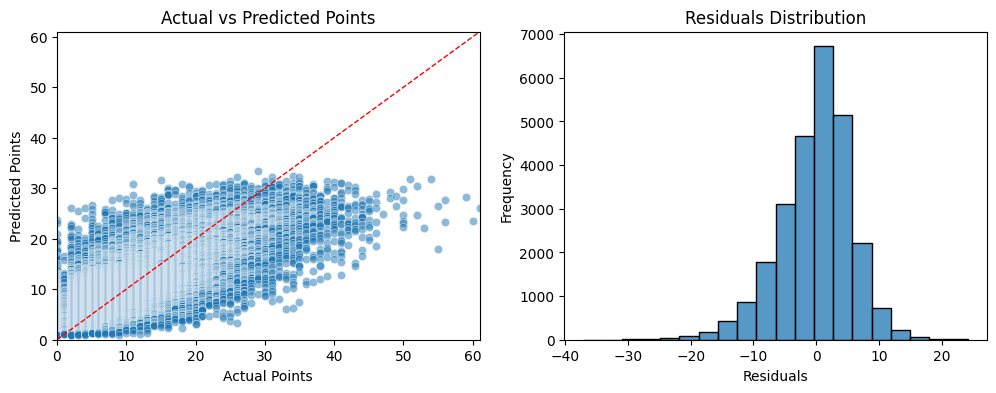

In [18]:
fig, axes = plt.subplots(1,2, figsize=(12, 4))

sns.scatterplot(x='actual', y='predicted', data=residuals_df, palette='light:m_r', alpha=0.5, ax=axes[0])
minVal = min(residuals_df['actual'].min(), residuals_df['predicted'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['predicted'].max())
axes[0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0].set_xlim(minVal, maxVal)
axes[0].set_ylim(minVal, maxVal)
axes[0].set_title('Actual vs Predicted Points')
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')

sns.histplot(residuals_df['residual'], bins=20, palette='light:m_r', ax=axes[1])
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.show()

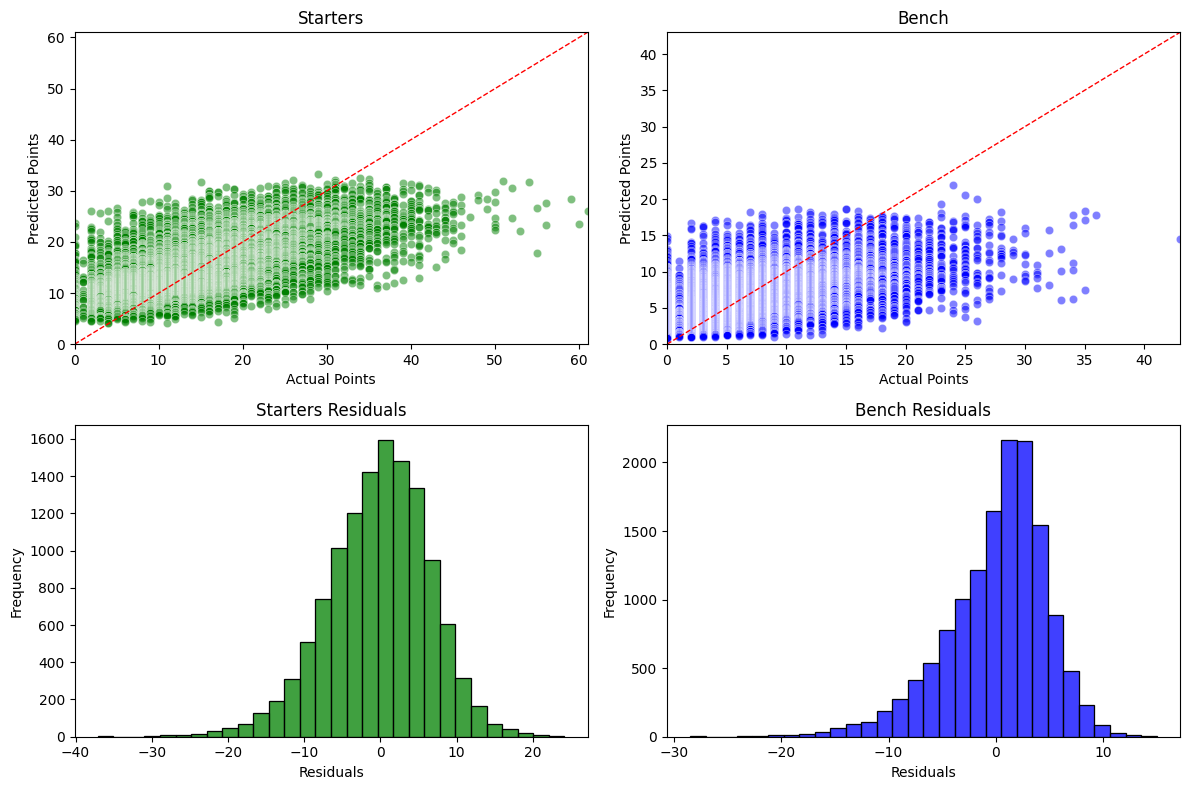

In [30]:
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # Made it taller for better visibility

sns.scatterplot(x='actual', y='predicted', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['predicted'].min())
maxVal = max(starters['actual'].max(), starters['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Starters')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['predicted'].min())
maxVal = max(bench['actual'].max(), bench['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Bench')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starters['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(bench['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()


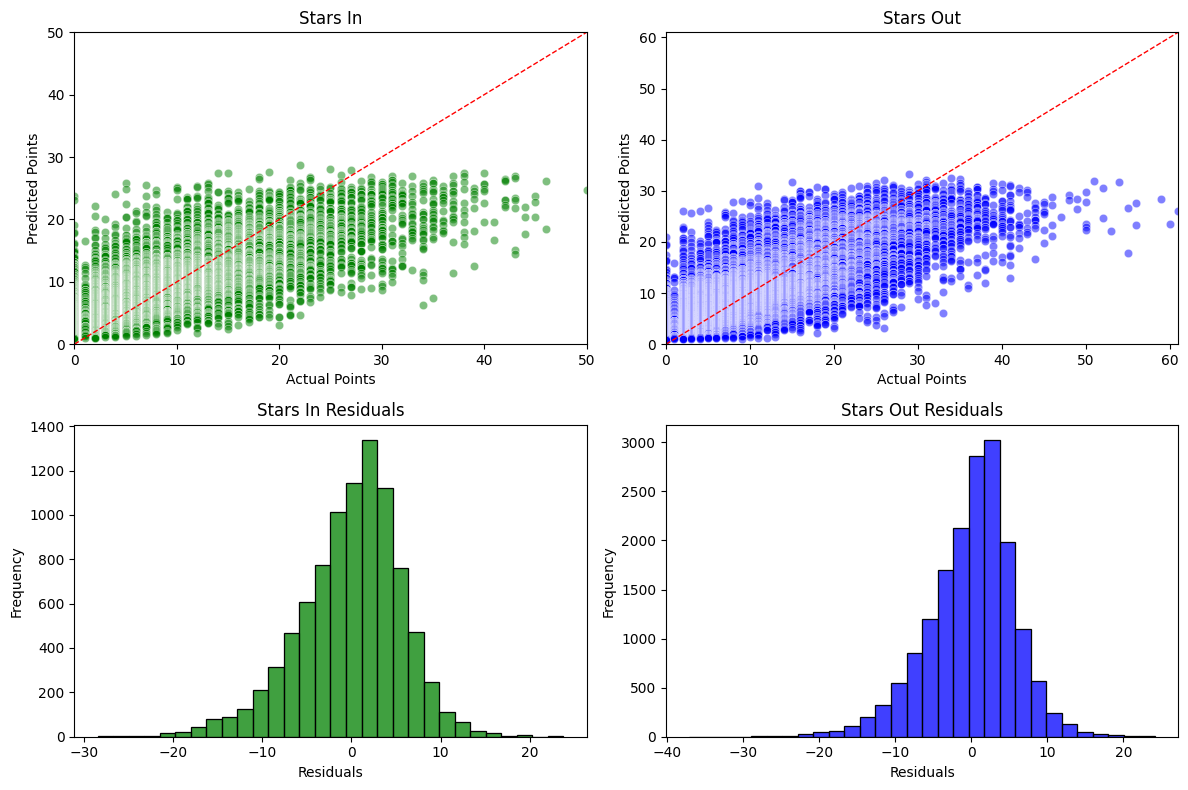

In [20]:
starsIn = residuals_df[residuals_df['TEAM_STAR_OUT'] == 1]
starsOut = residuals_df[residuals_df['TEAM_STAR_OUT'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=starsIn, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starsIn['actual'].min(), starsIn['predicted'].min())
maxVal = max(starsIn['actual'].max(), starsIn['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Stars In')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=starsOut, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(starsOut['actual'].min(), starsOut['predicted'].min())
maxVal = max(starsOut['actual'].max(), starsOut['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Stars Out')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starsIn['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Stars In Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(starsOut['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Stars Out Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()



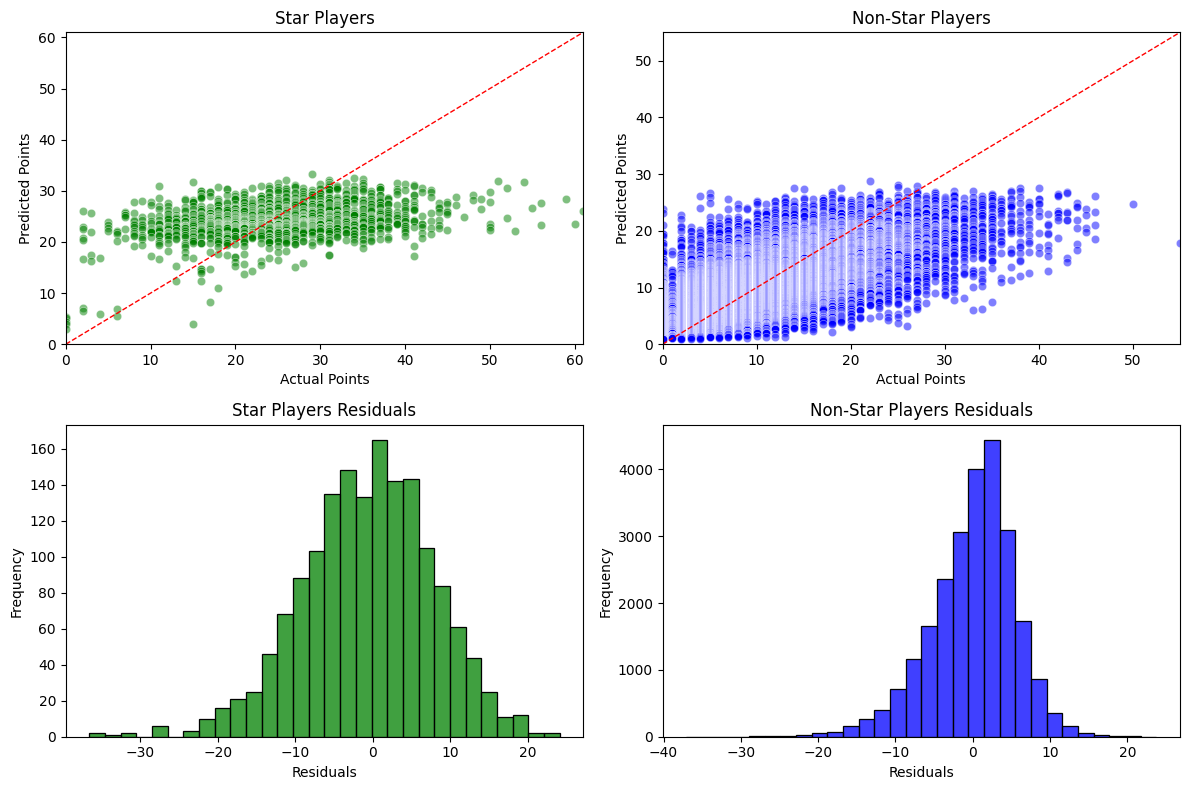

In [21]:
starPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 1]
nonStarPlayers = residuals_df[residuals_df['PLAYER_IS_TEAM_STAR'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=starPlayers, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starPlayers['actual'].min(), starPlayers['predicted'].min())
maxVal = max(starPlayers['actual'].max(), starPlayers['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Star Players')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=nonStarPlayers, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonStarPlayers['actual'].min(), nonStarPlayers['predicted'].min())
maxVal = max(nonStarPlayers['actual'].max(), nonStarPlayers['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Non-Star Players')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(starPlayers['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Star Players Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonStarPlayers['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Star Players Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

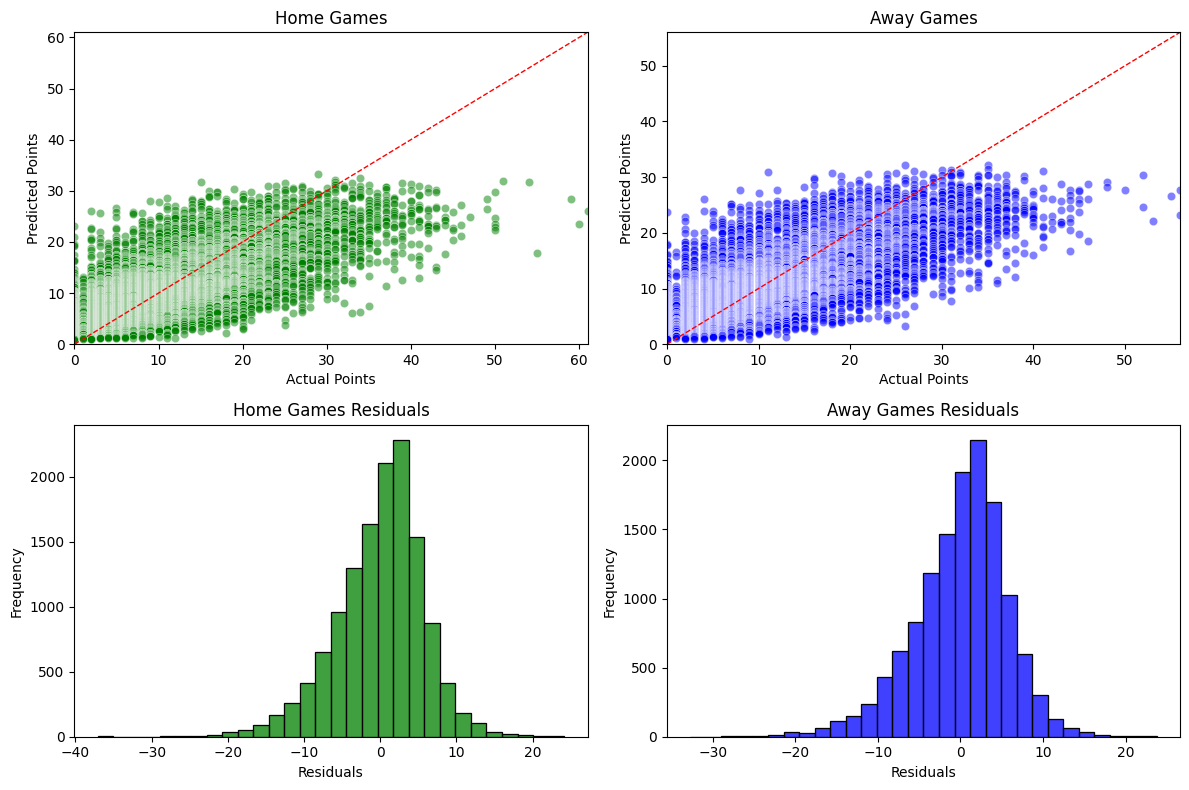

In [22]:
homeGames = residuals_df[residuals_df['HOME_GAME'] == 1]
awayGames = residuals_df[residuals_df['HOME_GAME'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=homeGames, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(homeGames['actual'].min(), homeGames['predicted'].min())
maxVal = max(homeGames['actual'].max(), homeGames['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Home Games')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=awayGames, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(awayGames['actual'].min(), awayGames['predicted'].min())
maxVal = max(awayGames['actual'].max(), awayGames['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Away Games')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(homeGames['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Home Games Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(awayGames['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Away Games Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

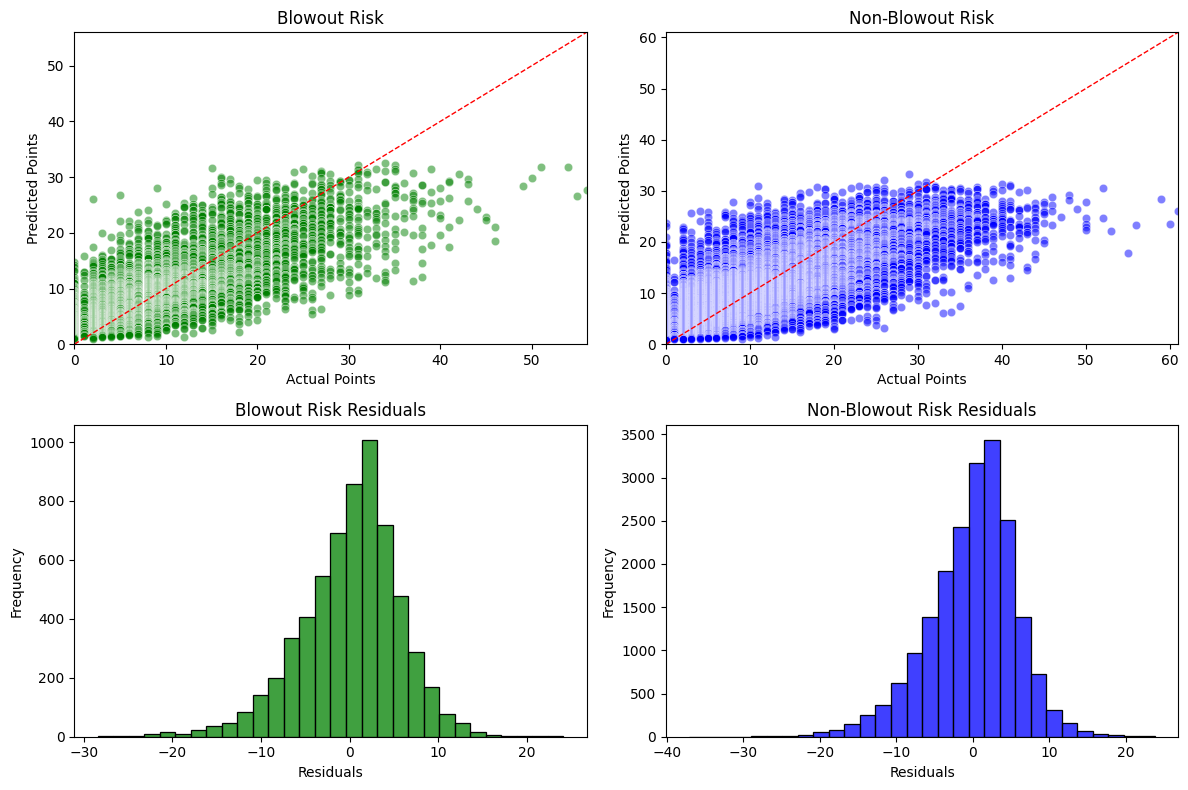

In [23]:
blowoutRisk = residuals_df[residuals_df['BLOWOUT_RISK'] == 1]
nonBlowoutRisk = residuals_df[residuals_df['BLOWOUT_RISK'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=blowoutRisk, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(blowoutRisk['actual'].min(), blowoutRisk['predicted'].min())
maxVal = max(blowoutRisk['actual'].max(), blowoutRisk['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('Blowout Risk')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=nonBlowoutRisk, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(nonBlowoutRisk['actual'].min(), nonBlowoutRisk['predicted'].min())
maxVal = max(nonBlowoutRisk['actual'].max(), nonBlowoutRisk['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Non-Blowout Risk')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(blowoutRisk['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Blowout Risk Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(nonBlowoutRisk['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Non-Blowout Risk Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

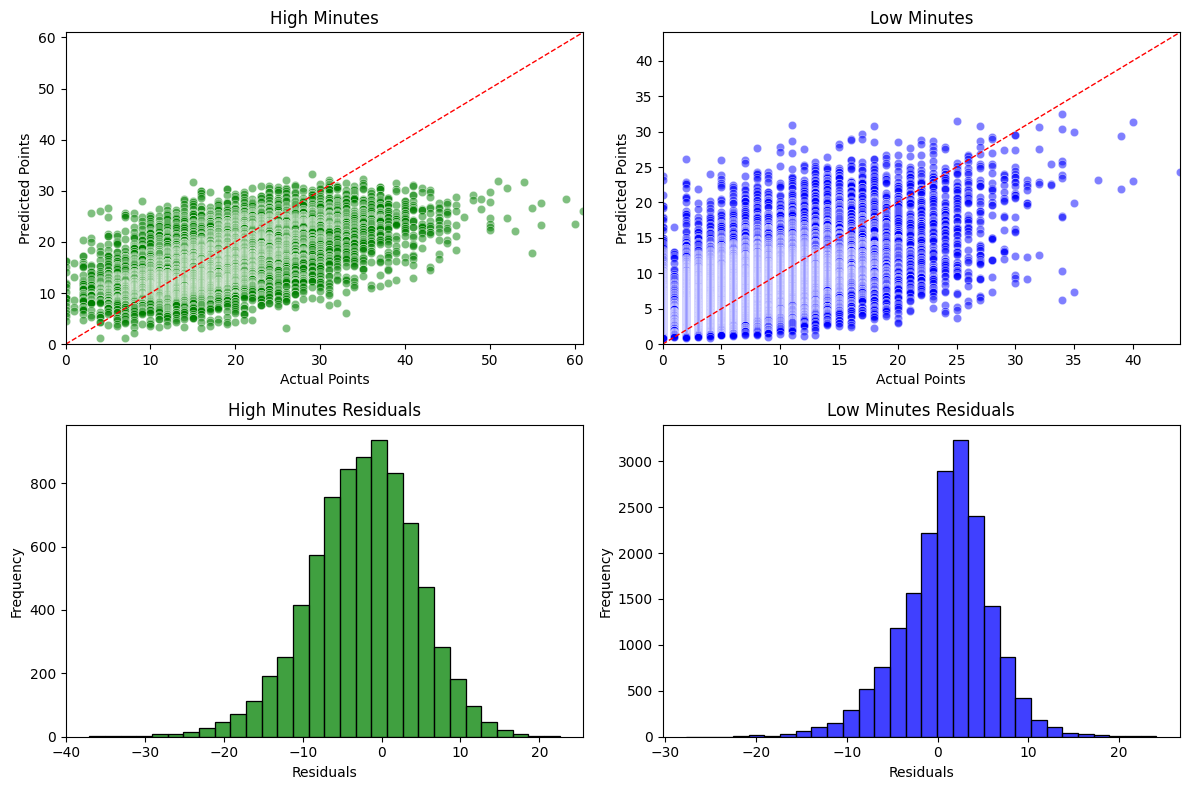

In [24]:
highMins = residuals_df[residuals_df['MIN'] > 30]
lowMins = residuals_df[residuals_df['MIN'] <= 30]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  

sns.scatterplot(x='actual', y='predicted', data=highMins, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(highMins['actual'].min(), highMins['predicted'].min())
maxVal = max(highMins['actual'].max(), highMins['predicted'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title('High Minutes')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

sns.scatterplot(x='actual', y='predicted', data=lowMins, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(lowMins['actual'].min(), lowMins['predicted'].min())
maxVal = max(lowMins['actual'].max(), lowMins['predicted'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title('Low Minutes')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

sns.histplot(highMins['residual'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('High Minutes Residuals')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

sns.histplot(lowMins['residual'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Low Minutes Residuals')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()